<a href="https://colab.research.google.com/github/smartypants85/MMR/blob/main/MMR_Sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 8.6 MB/s eta 0:00:00


/tmp/ipykernel_3259/2437250211.py:83: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  inputs = saltelli.sample(problem, POINTS)


Streaming output truncated to the last 5000 lines.
Sample 13433/18432
Sample 13434/18432
Sample 13435/18432
Sample 13436/18432
Sample 13437/18432
Sample 13438/18432
Sample 13439/18432
Sample 13440/18432
Sample 13441/18432
Sample 13442/18432
Sample 13443/18432
Sample 13444/18432
Sample 13445/18432
Sample 13446/18432
Sample 13447/18432
Sample 13448/18432
Sample 13449/18432
Sample 13450/18432
Sample 13451/18432
Sample 13452/18432
Sample 13453/18432
Sample 13454/18432
Sample 13455/18432
Sample 13456/18432
Sample 13457/18432
Sample 13458/18432
Sample 13459/18432
Sample 13460/18432
Sample 13461/18432
Sample 13462/18432
Sample 13463/18432
Sample 13464/18432
Sample 13465/18432
Sample 13466/18432
Sample 13467/18432
Sample 13468/18432
Sample 13469/18432
Sample 13470/18432
Sample 13471/18432
Sample 13472/18432
Sample 13473/18432
Sample 13474/18432
Sample 13475/18432
Sample 13476/18432
Sample 13477/18432
Sample 13478/18432
Sample 13479/18432
Sample 13480/18432
Sample 13481/18432
Sample 13482/18432

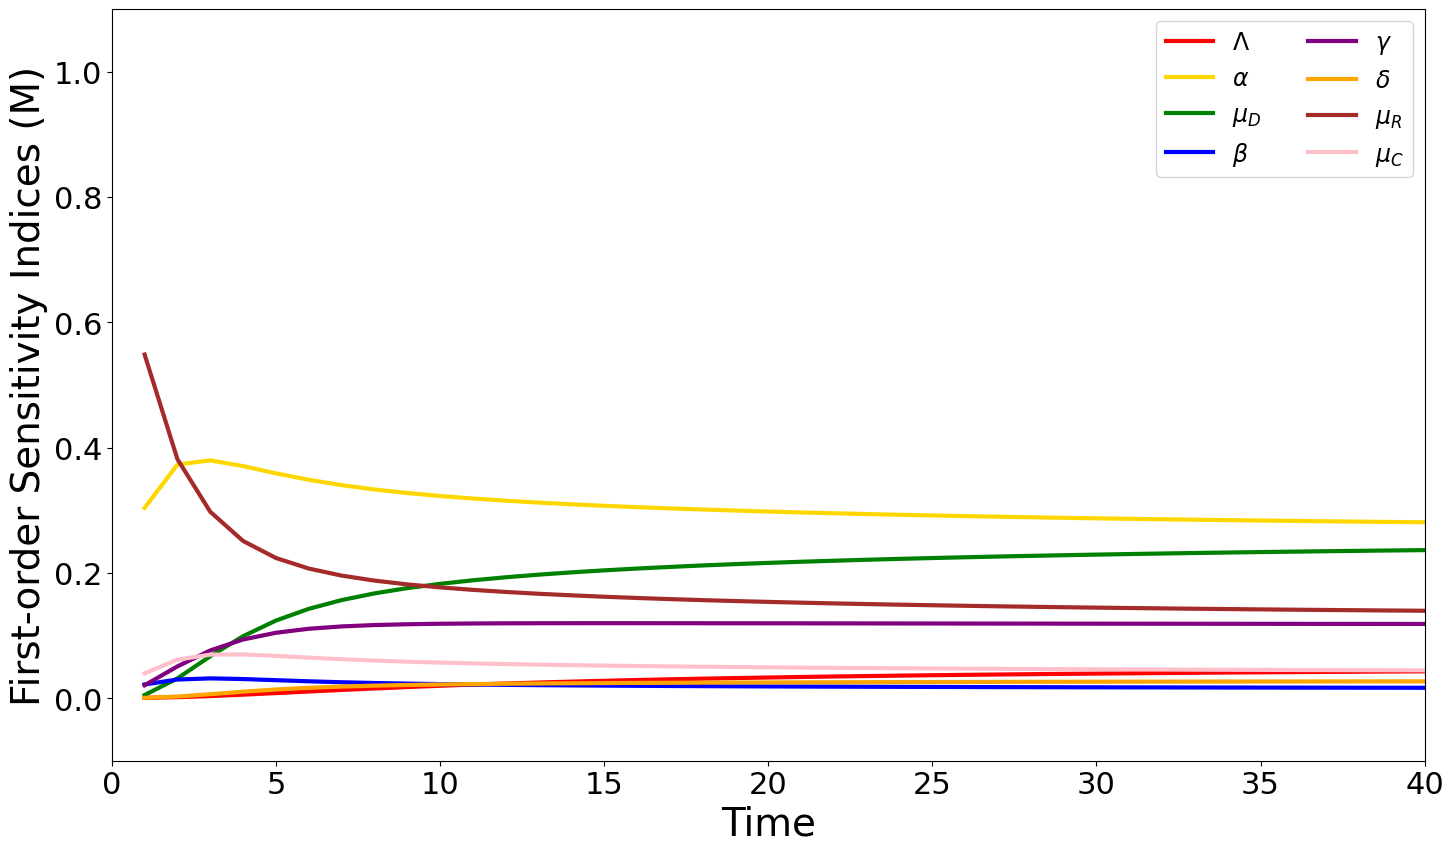

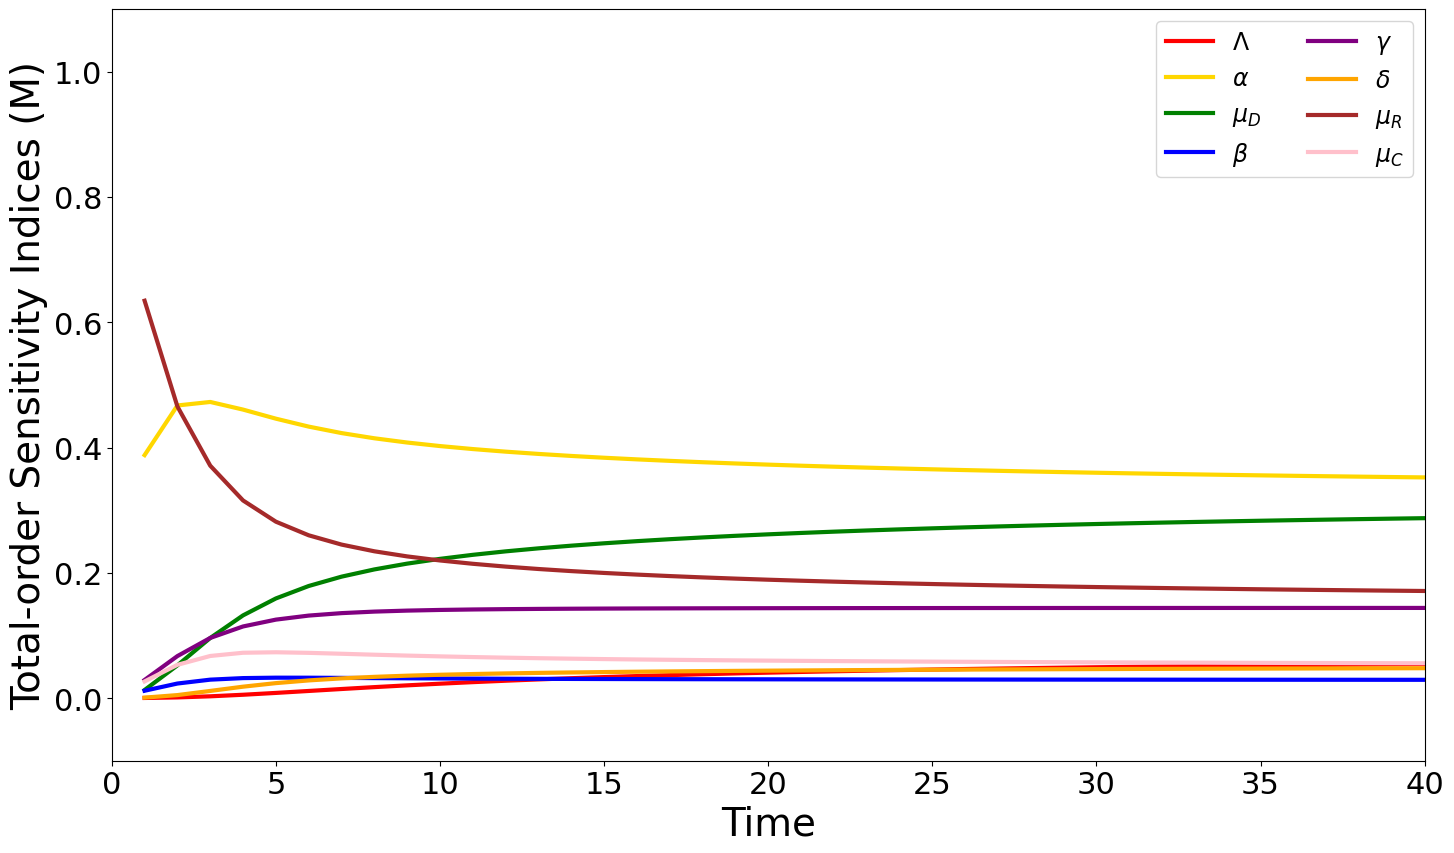

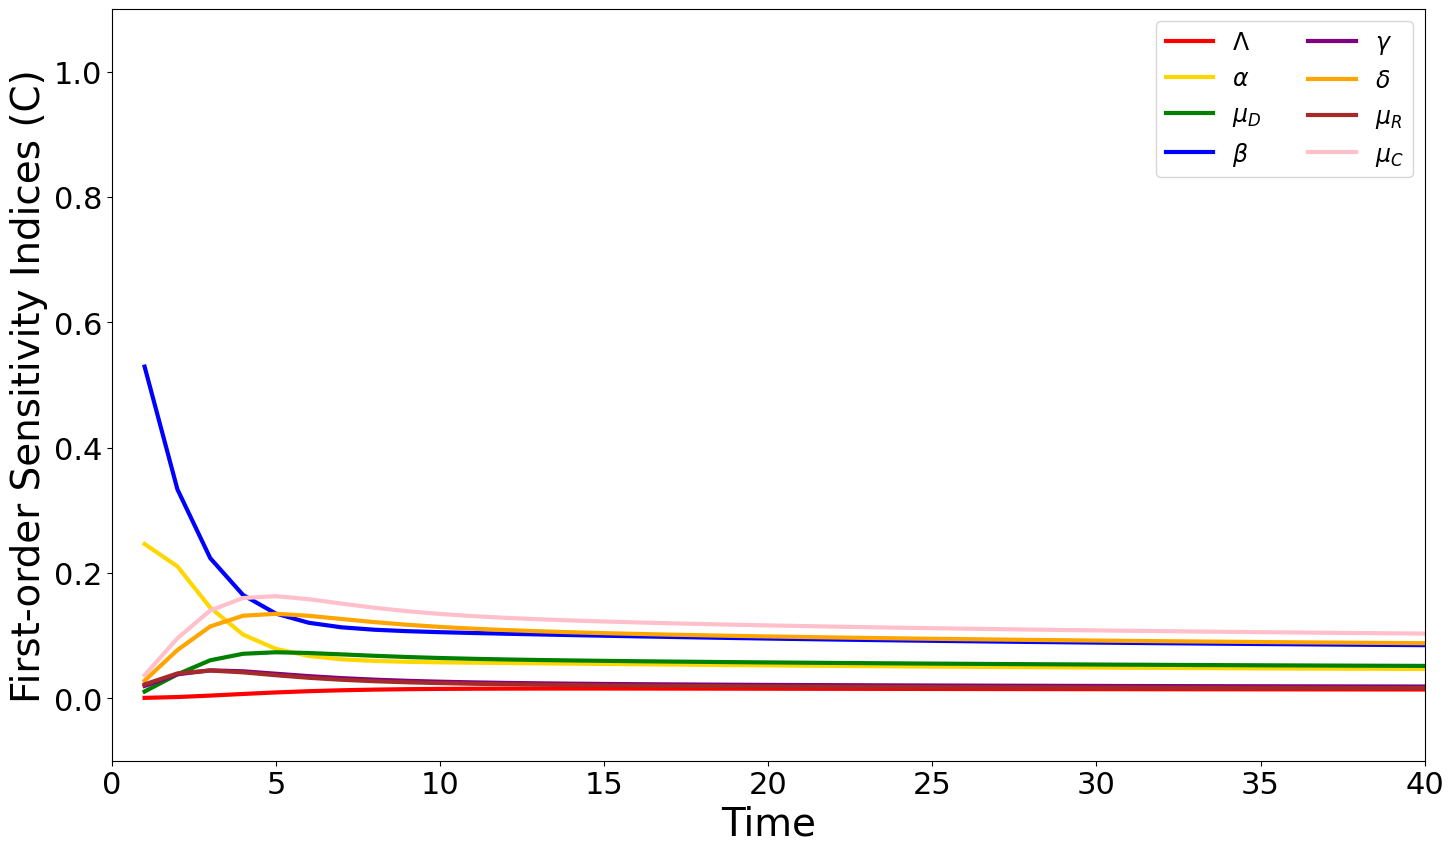

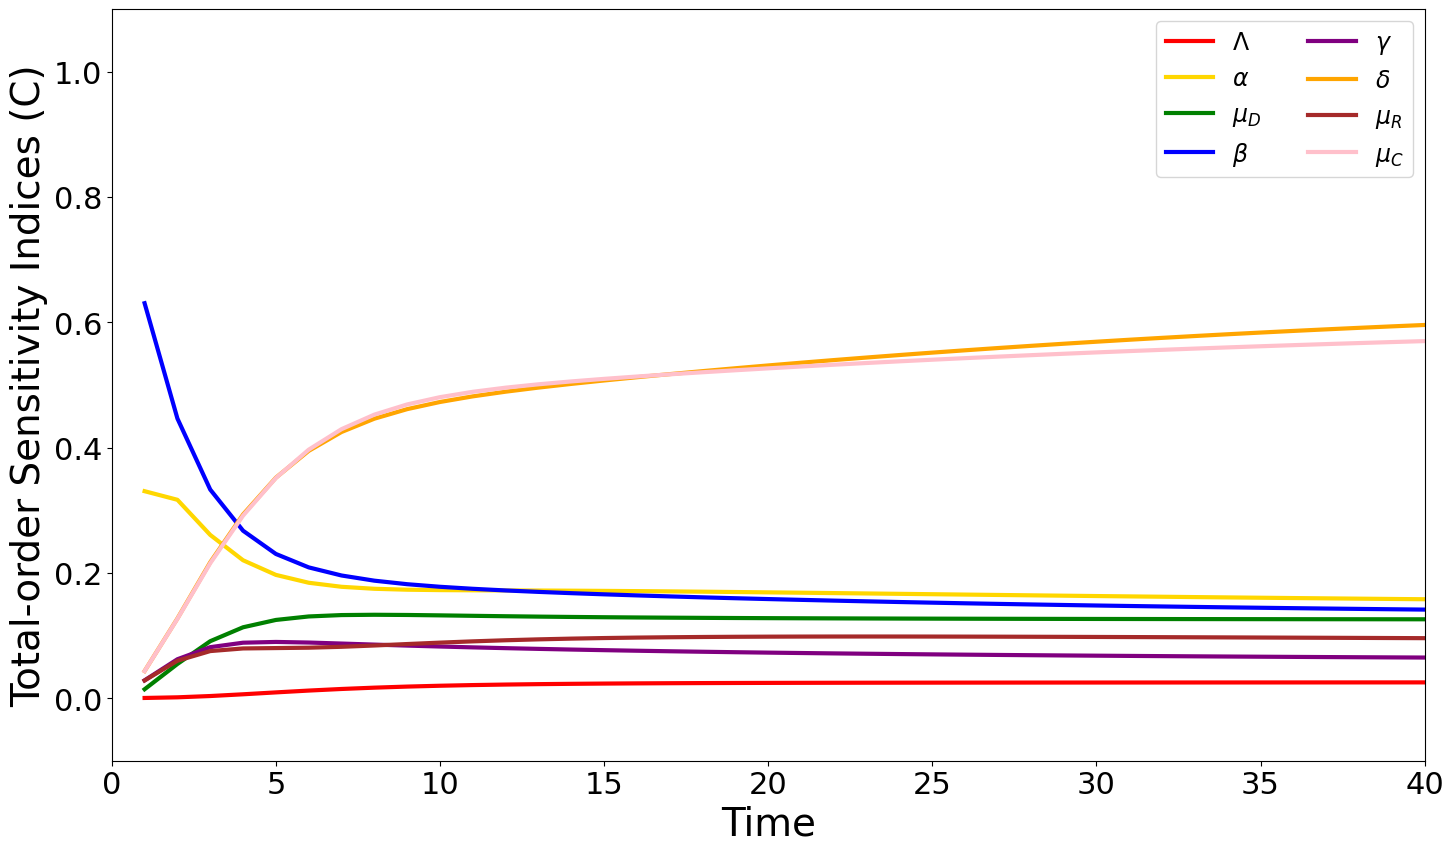

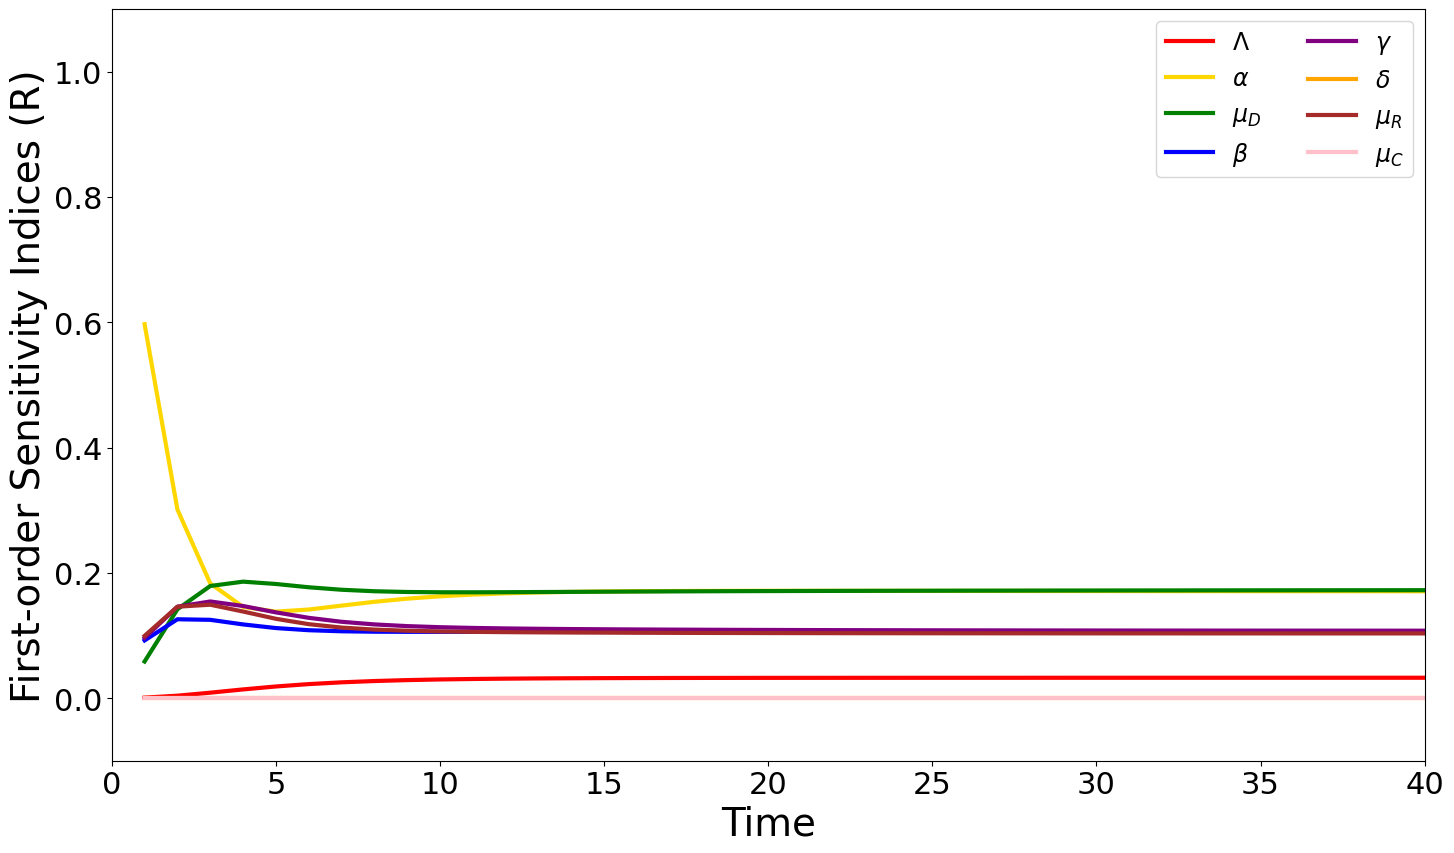

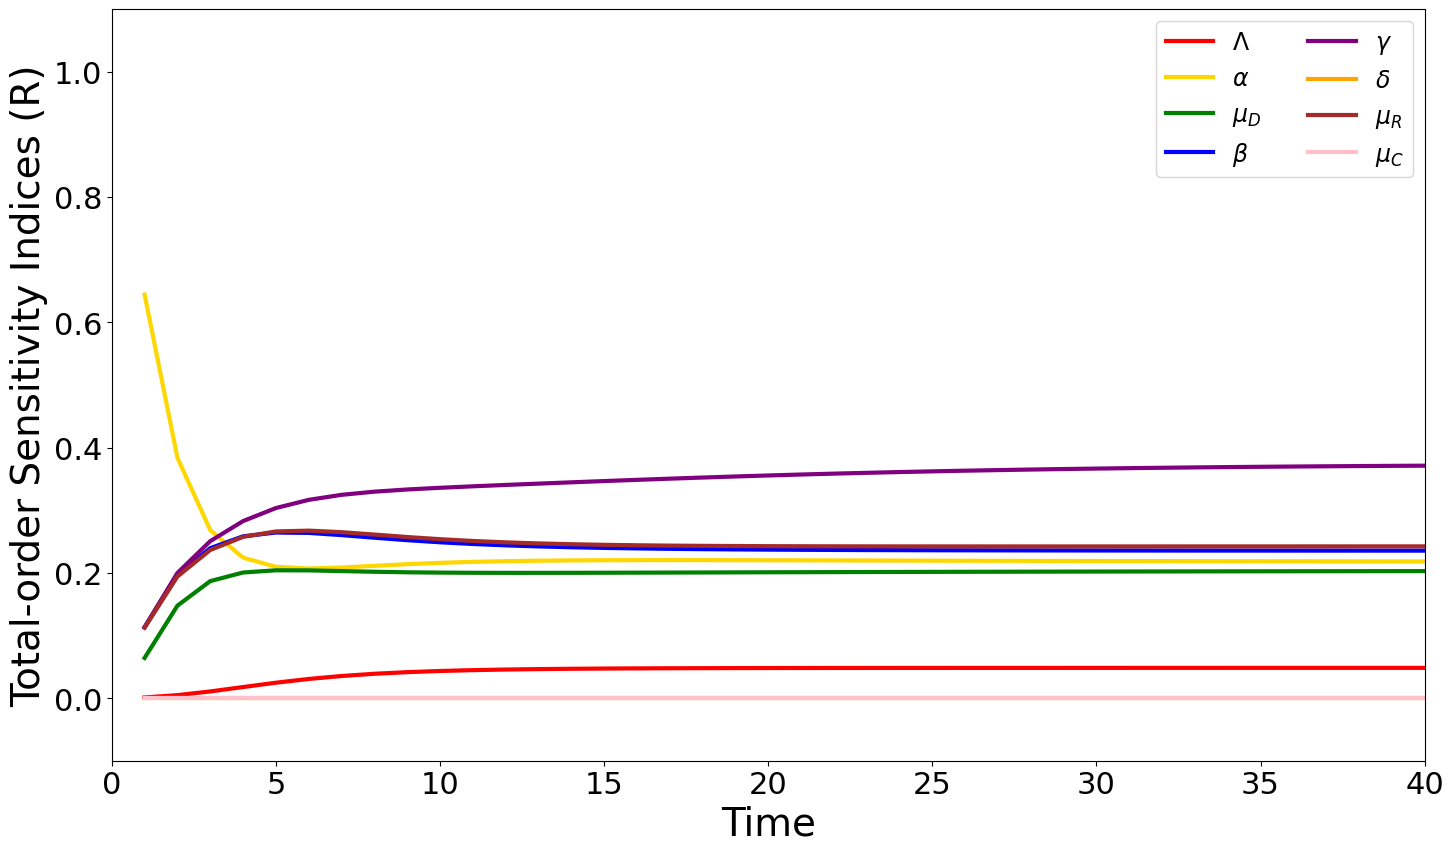

In [ ]:
!pip install SALib

from SALib.sample import saltelli
from SALib.analyze import sobol
import numpy as np
import scipy
import matplotlib.pyplot as plt

INTERVAL = [0, 40]
POINTS_ALONG_INTERVAL = 101
TRUE_PARAMETER = (
    100000.0,   # Lambda
    0.03176,    # alpha
    0.01000,    # muD
    0.03437,    # beta
    0.99500,    # gamma
    0.88600,    # delta
    0.00100,    # muR
    0.11400     # muC
)

PARAMETER_SYMBOLS = [
    r"$\Lambda$", r"$\alpha$", r"$\mu_D$", r"$\beta$",
    r"$\gamma$", r"$\delta$", r"$\mu_R$", r"$\mu_C$"
]

INITIAL_CONDITION = [
    565000,    # S0
    75000,     # R0
    750,       # C0
    0,         # M0
    0          # E0
]


def mmr_system(y, t, Lambda, alpha, muD, beta, gamma, delta, muR, muC):
    S, R, C, M, E = y

    S = max(S, 0)
    R = max(R, 0)
    C = max(C, 0)
    M = max(M, 0)
    E = max(E, 0)

    dSdt = Lambda - alpha * S - muD * S

    dRdt = alpha * S - beta * R - gamma * R - muR * R

    dCdt = beta * R - delta * C - muC * C

    dMdt = muR * R + muC * C

    dEdt = delta * C + gamma * R

    return [dSdt, dRdt, dCdt, dMdt, dEdt]


DAY_SPACING = 1

POINTS = 2**10

LAMBDA_INDEX = 0
LAMBDA_BOUND_FACTOR = 0.25

problem = {
    'num_vars': len(PARAMETER_SYMBOLS),
    'names': PARAMETER_SYMBOLS,
    'bounds': []
}

for ii in range(len(TRUE_PARAMETER)):
    baseline_value = TRUE_PARAMETER[ii]

    if ii == LAMBDA_INDEX:
        lower_bound = baseline_value * (1 - LAMBDA_BOUND_FACTOR)
        upper_bound = baseline_value * (1 + LAMBDA_BOUND_FACTOR)
    else:
        lower_bound = 0
        upper_bound = 1

    problem['bounds'].append([lower_bound, upper_bound])

inputs = saltelli.sample(problem, POINTS)

num_time_steps = INTERVAL[1] - INTERVAL[0]

OUTPUT_STATE_INDICES = {
    'M': 3,
    'C': 2,
    'R': 1
}

outputs = {name: [] for name in OUTPUT_STATE_INDICES}
t = []

for ii in range(num_time_steps):
    for name in outputs:
        outputs[name].append([])
    t.append((ii + 1) * DAY_SPACING)

for sampleEntry in range(len(inputs)):
    print(f'Sample {sampleEntry + 1}/{len(inputs)}')

    modified_parameters = inputs[sampleEntry]
    modified_initial_conditions = INITIAL_CONDITION.copy()

    for ii in range(num_time_steps):
        time = np.linspace(
            ii * DAY_SPACING,
            (ii + 1) * DAY_SPACING,
            POINTS_ALONG_INTERVAL
        )

        sol = scipy.integrate.odeint(
            mmr_system,
            modified_initial_conditions,
            time,
            args=tuple(modified_parameters)
        )

        for name, state_index in OUTPUT_STATE_INDICES.items():
            outputs[name][ii].append(sol[-1][state_index])

        modified_initial_conditions = [
            sol[-1][0], sol[-1][1], sol[-1][2], sol[-1][3], sol[-1][4]
        ]

for name in outputs:
    outputs[name] = np.array(outputs[name])

Si_F = {name: [] for name in outputs}
Si_F_conf = {name: [] for name in outputs}

Si_T = {name: [] for name in outputs}
Si_T_conf = {name: [] for name in outputs}

for name in outputs:
    for ii in range(num_time_steps):

        sobol_analysis = sobol.analyze(
            problem,
            outputs[name][ii],
            print_to_console=False
        )

        Si_F[name].append(sobol_analysis['S1'])
        Si_F_conf[name].append(sobol_analysis['S1_conf'])

        Si_T[name].append(sobol_analysis['ST'])
        Si_T_conf[name].append(sobol_analysis['ST_conf'])

    Si_F[name] = np.clip(np.array(Si_F[name]), 0, 1)
    Si_T[name] = np.clip(np.array(Si_T[name]), 0, 1)

np.save("t_mmr.npy", np.array(t))
for name in outputs:
    np.save(f"Si_{name}_F.npy", Si_F[name])
    np.save(f"Si_{name}_T.npy", Si_T[name])
np.save("PARAMETER_SYMBOLS_mmr.npy", np.array(PARAMETER_SYMBOLS, dtype=object))


plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 28,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 17
})

PLOT_COLORS = [
    "red", "gold", "green", "blue", "purple", "orange", "brown",
    "pink", "gray", "cyan", "olive", "black", "magenta", "navy",
    "teal", "lime", "coral", "darkviolet", "darkred", "darkgreen"
]

PLOT_LINESTYLES = [
    "-", "--", "-.", ":"
]

def get_plot_style(jj):
    color = PLOT_COLORS[jj % len(PLOT_COLORS)]
    linestyle = PLOT_LINESTYLES[(jj // len(PLOT_COLORS)) % len(PLOT_LINESTYLES)]
    return color, linestyle


def plot_indices(Si, ylabel, filename):
    fig, ax1 = plt.subplots(figsize=(15, 9))

    lines = []
    for jj in range(len(PARAMETER_SYMBOLS)):
        color, linestyle = get_plot_style(jj)

        line = ax1.plot(
            t,
            [Si[ii][jj] for ii in range(len(Si))],
            color=color,
            linestyle=linestyle,
            linewidth=3,
            label=PARAMETER_SYMBOLS[jj]
        )

        lines += line

    ax1.tick_params(axis='both', labelsize=22)
    ax1.set_ylim([-0.1, 1.1])
    ax1.set_xlim([INTERVAL[0], INTERVAL[1]])

    labs = [l.get_label() for l in lines]
    ax1.legend(lines, labs, loc='best', fontsize=17, ncol=2)

    ax1.set_ylabel(ylabel, fontsize=28)
    ax1.set_xlabel(r"Time", fontsize=28)

    fig.tight_layout()

    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()


for name in outputs:
    plot_indices(
        Si_F[name],
        rf"First-order Sensitivity Indices ({name})",
        f"MMR_Sensitivity_First_order_{name}.png"
    )

    plot_indices(
        Si_T[name],
        rf"Total-order Sensitivity Indices ({name})",
        f"MMR_Sensitivity_Total_order_{name}.png"
    )